# Assignment 2: APIs, Data Formats, Databases, and EDA

---

## Submission Instructions

Submit only a link to the folder for Assignment 2 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment2.ipynb` or something similar, placed inside the `assignments/assignment2/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

used ai to learn the function of unknown libraries, debuff codes, help with SQL part code, and clarify and improve coding.

## Grading

This assignment is worth 10 points. Task 0 is worth 2 points, and tasks 1-8 are worth 1 point each.

Points are given only for code that runs. If the code does not run, the task will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).

---

## Tasks

### Task 0: Course project dataset exploration (2p)

This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.

a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using `.describe()`) and creating at least 2 visualizations of the data. (1p)

a) Dataset selection

World Happiness Report 2019 Dataset (Kaggle)
Link: https://www.kaggle.com/datasets/unsdsn/world-happiness

b) Briefly describe the dataset

This dataset contains happiness scores and rankings for 156 countries, based on the Gallup World Poll. It includes economic, social, and governance indicators as potential factors influencing happiness. The main variable is the Happiness Score, along with explanatory variables such as GDP per capita, social support, healthy life expectancy, freedom, generosity, and perceptions of corruption. Each yearly file includes approximately 156 rows and 9 columns.
this project plans to analyze which factors most strongly predict a country's happiness score, compare happiness across regions, and build a regression model to predict happiness scores from the other variables.

Shape (rows, columns): (156, 9)

Column names: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

Missing values per column:
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


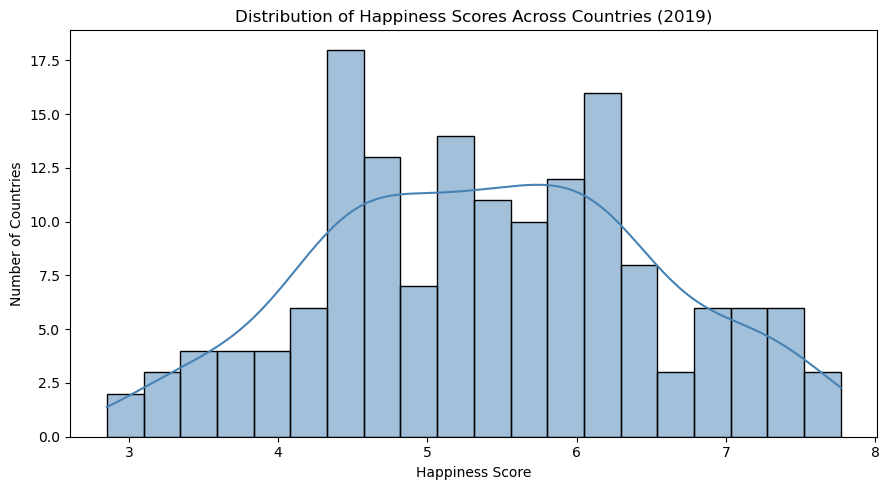

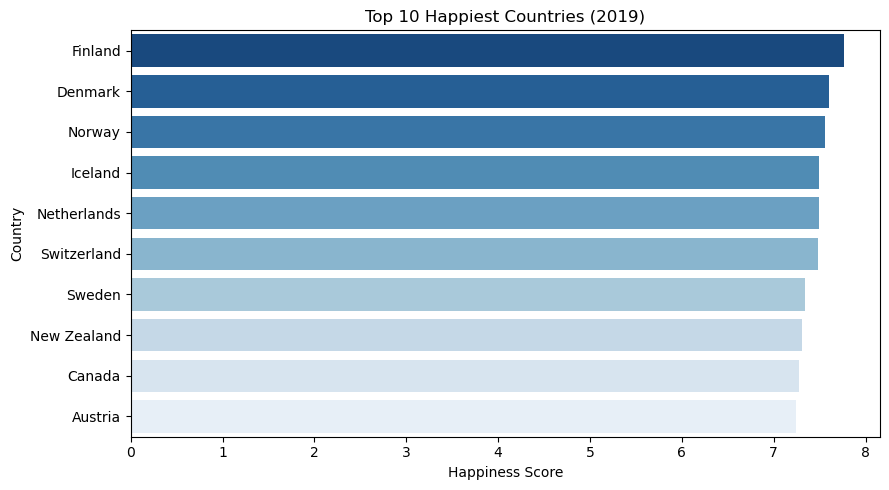

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\11317\Downloads\2019.csv")

# Basic overview
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values per column:")
print(df.isnull().sum())
# Preview first 5 rows
display(df.head())

#c) Exploratory Data Analysis
# Summary statistics for all numerical columns
display(df.describe())

# Visualization 1: Distribution of Happiness Scores
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Score",
    bins=20,
    kde=True,           # smooth curve on top
    color="steelblue"
)

plt.title("Distribution of Happiness Scores Across Countries (2019)")
plt.xlabel("Happiness Score")
plt.ylabel("Number of Countries")

plt.tight_layout()
plt.show()

# Visualization 3: Top 10 Happiest Countries
top10 = df.nlargest(10, "Score")

plt.figure(figsize=(9, 5))

sns.barplot(
    data=top10,
    x="Score",
    y="Country or region",
    hue="Country or region",
    palette="Blues_r"
)

plt.title("Top 10 Happiest Countries (2019)")
plt.xlabel("Happiness Score")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [2]:
import os
import json
import time
import sqlite3
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

In [3]:
load_dotenv()                                        # load variables from .env file into environment
api_key = os.getenv("MARKETSTACK_API_KEY")           # read the API key from environment
print(api_key[:5] + "...")                           # print only first 5 characters to confirm it loaded

948e0...


### Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [4]:
# a) Fetch FAANG stock data for March 2026
params = {
    "access_key": api_key,                           # API key loaded from .env
    "symbols": "META,AAPL,AMZN,NFLX,GOOG",          # FAANG ticker symbols
    "date_from": "2026-03-01",                       # start of March 2026
    "date_to": "2026-03-31",                         # end of March 2026
    "limit": 1000                                    # ensure all records are retrieved
}

response = requests.get("https://api.marketstack.com/v1/eod", params=params)  # send GET request
json_data = response.json()                          # parse JSON response

print("Status code:", response.status_code)          # 200 means success
print("Records retrieved:", len(json_data["data"]))  # should be ~105 (5 stocks x ~21 trading days)

# b) Convert to DataFrame
df_stocks = pd.DataFrame(json_data["data"])                                          # convert JSON to DataFrame
df_stocks["date"] = pd.to_datetime(df_stocks["date"])                                # convert date column to datetime
df_stocks = df_stocks[["symbol", "date", "open", "close", "high", "low", "volume"]] # keep only relevant columns
df_stocks = df_stocks.sort_values(["symbol", "date"]).reset_index(drop=True)         # sort by symbol and date

print("First 5 rows:")
display(df_stocks.head())

# c) Summary statistics and monthly returns
summary = df_stocks.groupby("symbol")["close"].describe()  # closing price stats per stock
print("Summary statistics:")
display(summary)

def monthly_return(group):
    group = group.sort_values("date")                                               # sort by date within each group
    first_close = group.iloc[0]["close"]                                            # first trading day close
    last_close = group.iloc[-1]["close"]                                            # last trading day close
    return round((last_close - first_close) / first_close * 100, 2)                # percentage change

returns = df_stocks.groupby("symbol").apply(
    monthly_return, include_groups=False                                            # include_groups=False suppresses deprecation warning
).rename("return_%")

print("Monthly returns:")
display(returns)

best = returns.idxmax()                                                             # stock with highest return
worst = returns.idxmin()                                                            # stock with lowest return
print(f"\nBest performance: {best}, return rate: {returns[best]:.2f}%")
print(f"Worst performance: {worst}, return rate: {returns[worst]:.2f}%")

Status code: 200
Records retrieved: 110
First 5 rows:


,symbol,date,open,close,high,low,volume
0,AAPL,2026-03-02 00:00:00+00:00,262.440,264.72,266.530,260.20,41576035.0
1,AAPL,2026-03-03 00:00:00+00:00,263.480,263.75,265.560,260.13,37994695.0
2,AAPL,2026-03-04 00:00:00+00:00,264.650,262.52,266.150,261.42,39258957.0
3,AAPL,2026-03-05 00:00:00+00:00,260.745,260.29,261.555,257.25,49424671.0
4,AAPL,2026-03-06 00:00:00+00:00,258.740,257.46,258.760,254.37,40628988.0


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


Monthly returns:


symbol
AAPL    -4.13
AMZN    -0.06
GOOG    -6.37
META   -12.46
NFLX    -0.97
Name: return_%, dtype: float64


Best performance: AMZN, return rate: -0.06%
Worst performance: META, return rate: -12.46%


### Task 3: Visualizing stock data (1p)

Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

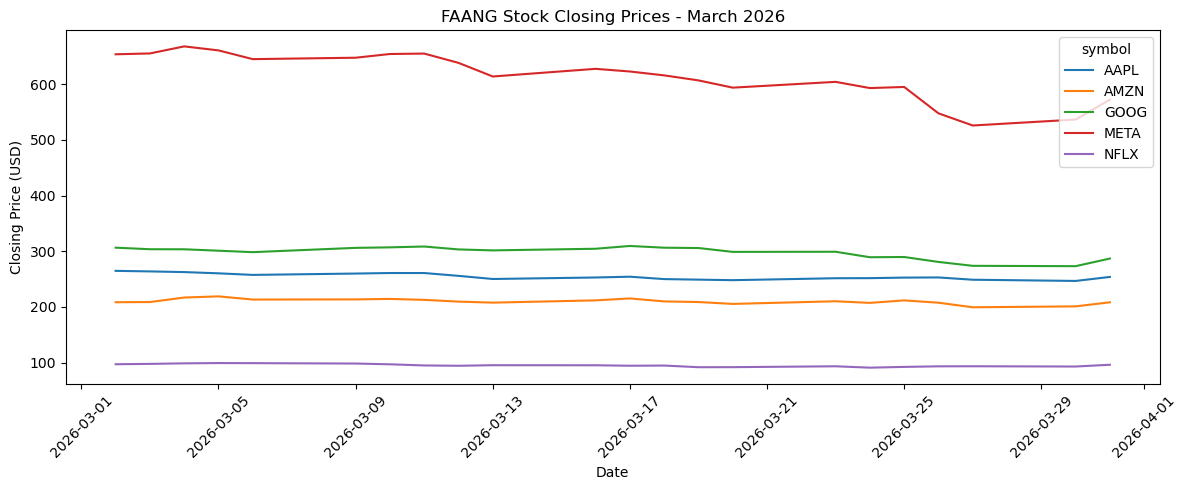

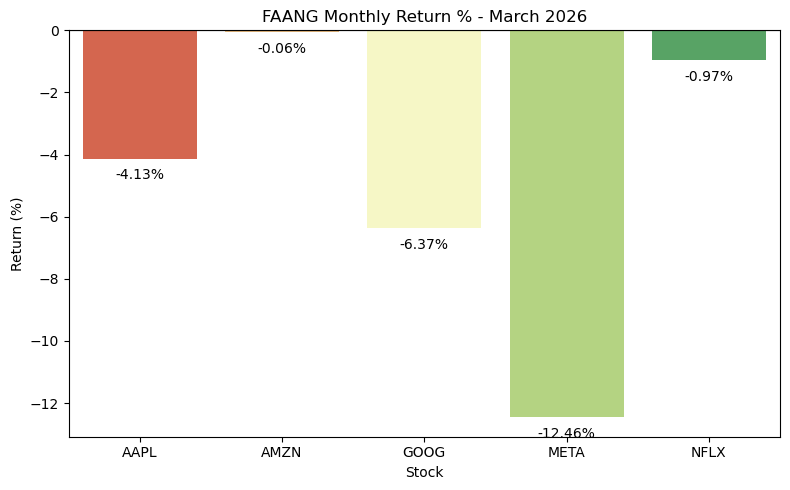

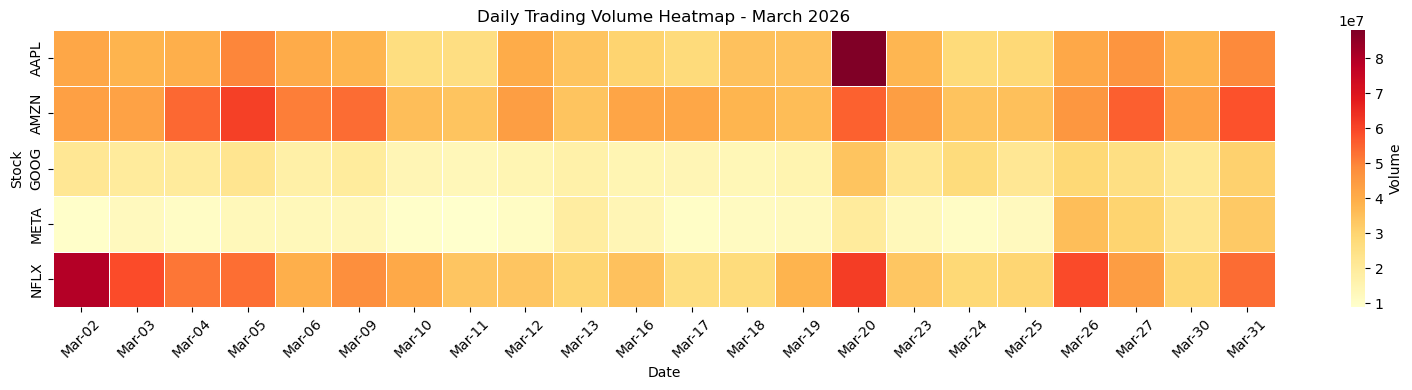

In [5]:
# a) Line chart: closing prices over time
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_stocks,
    x="date",
    y="close",
    hue="symbol"                                     # different color per stock
)
plt.title("FAANG Stock Closing Prices - March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# b) Bar plot: monthly return percentage
returns_df = returns.reset_index()                   # convert Series to DataFrame for plotting
returns_df.columns = ["symbol", "return_%"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=returns_df,
    x="symbol",
    y="return_%",
    hue="symbol",                                    # required to use palette without warning
    palette="RdYlGn",                                # red = negative, green = positive
    legend=False
)
for i, row in returns_df.iterrows():                 # add return % labels on each bar
    plt.text(i, row["return_%"] - 0.3, f'{row["return_%"]:.2f}%', ha="center", va="top", fontsize=10)
plt.axhline(y=0, color="black", linewidth=0.8)       # reference line at 0%
plt.title("FAANG Monthly Return % - March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")
plt.tight_layout()
plt.show()

# c) Heatmap: daily trading volume
pivot_volume = df_stocks.pivot(
    index="symbol",                                  # stocks on y-axis
    columns="date",                                  # dates on x-axis
    values="volume"                                  # fill with trading volume
)
pivot_volume.columns = pivot_volume.columns.strftime("%b-%d")  # simplify date labels e.g. "Mar-02"

plt.figure(figsize=(16, 4))
sns.heatmap(
    pivot_volume,
    cmap="YlOrRd",                                   # yellow = low volume, red = high volume
    linewidths=0.5,                                  # borders between cells
    cbar_kws={"label": "Volume"}                     # color bar label
)
plt.title("Daily Trading Volume Heatmap - March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 4: Exporting and importing data (1p)

a) Export the JSON data retrieved in Task 2a as a JSON file `stockdata.json` into a subfolder called `exports`.

b) Export the DataFrame from Task 2b as a CSV file `stockdata.csv` into the same `exports` subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [6]:
# a) Export JSON
os.makedirs("exports", exist_ok=True)                # create exports folder if it doesn't exist
with open("exports/stockdata.json", "w") as f:
    json.dump(json_data, f)                          # write raw JSON data to file
print("✓ JSON exported successfully")

# b) Export CSV
df_stocks.to_csv("exports/stockdata.csv", index=False)  # save DataFrame as CSV without row index
print("✓ CSV exported successfully")

# c) Load back and verify
with open("exports/stockdata.json", "r") as f:
    loaded_json = json.load(f)                       # read JSON file back

df_from_json = pd.DataFrame(loaded_json["data"])                                            # convert to DataFrame
df_from_json["date"] = pd.to_datetime(df_from_json["date"])                                 # convert date column
df_from_json = df_from_json[["symbol", "date", "open", "close", "high", "low", "volume"]]  # keep relevant columns
df_from_json = df_from_json.sort_values(["symbol", "date"]).reset_index(drop=True)          # sort to match original

print("Loaded from JSON:")
display(df_from_json.head())

df_from_csv = pd.read_csv("exports/stockdata.csv")   # read CSV file back
df_from_csv["date"] = pd.to_datetime(df_from_csv["date"])  # convert date column

print("Loaded from CSV:")
display(df_from_csv.head())

✓ JSON exported successfully
✓ CSV exported successfully
Loaded from JSON:


,symbol,date,open,close,high,low,volume
0,AAPL,2026-03-02 00:00:00+00:00,262.440,264.72,266.530,260.20,41576035.0
1,AAPL,2026-03-03 00:00:00+00:00,263.480,263.75,265.560,260.13,37994695.0
2,AAPL,2026-03-04 00:00:00+00:00,264.650,262.52,266.150,261.42,39258957.0
3,AAPL,2026-03-05 00:00:00+00:00,260.745,260.29,261.555,257.25,49424671.0
4,AAPL,2026-03-06 00:00:00+00:00,258.740,257.46,258.760,254.37,40628988.0


Loaded from CSV:


,symbol,date,open,close,high,low,volume
0,AAPL,2026-03-02 00:00:00+00:00,262.440,264.72,266.530,260.20,41576035.0
1,AAPL,2026-03-03 00:00:00+00:00,263.480,263.75,265.560,260.13,37994695.0
2,AAPL,2026-03-04 00:00:00+00:00,264.650,262.52,266.150,261.42,39258957.0
3,AAPL,2026-03-05 00:00:00+00:00,260.745,260.29,261.555,257.25,49424671.0
4,AAPL,2026-03-06 00:00:00+00:00,258.740,257.46,258.760,254.37,40628988.0


### Task 5: Querying the Northwind database (1p)

Download an SQLite version of Microsoft's Northwind database (from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing `ProductName`, `UnitPrice`, and `UnitsInStock`. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the `Orders`, `Customers`, and `Order Details` tables to show `CompanyName`, `OrderID`, `OrderDate`, `ShipCountry`, and the line total (`UnitPrice * Quantity`) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

Hint: The SQL query in 5c should look something like this:

```
    SELECT columnNameX,
           columnNameX,
           columnNameX,
           columnNameX,
           columnNameX * columnNameX AS LineTotal
    FROM SomeTable o
    JOIN SomeTable c ON SomeTable.id = OtherTable.id
    JOIN SomeTable od ON SomeTable.id = OtherTable.id
    WHERE columnName = countryName
```

Hint: If you are unfamiliar with SQL, using AI to write the queries is a good idea. Remember to verify though that the column and table names are correct and not hallucinated. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [7]:
# a) Connect to database and list all tables
conn = sqlite3.connect("Northwind.db")               # connect to SQLite database
print("✓ Database connected successfully")

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",  # query to retrieve all table names
    conn
)
print("Tables in database:")
display(tables)

# b) Products with unit price above 30
query_b = """
SELECT ProductName, 
       UnitPrice, 
       UnitsInStock
FROM Products
WHERE UnitPrice > 30
ORDER BY UnitPrice DESC
"""
df_b = pd.read_sql(query_b, conn)                    # load query result into DataFrame
print(f"Products with unit price above 30 ({len(df_b)} found):")
display(df_b)

# c) Orders shipped to Germany (three-table join)
query_c = """
SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN 'Order Details' od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
"""
df_c = pd.read_sql(query_c, conn)                    # load query result into DataFrame
print(f"Orders shipped to Germany ({len(df_c)} records found):")
display(df_c.head())

✓ Database connected successfully
Tables in database:


,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


Products with unit price above 30 (24 found):


,ProductName,UnitPrice,UnitsInStock
0,Côte de Blaye,263.50,17
1,Thüringer Rostbratwurst,123.79,0
2,Mishi Kobe Niku,97.00,29
3,Sir Rodney's Marmalade,81.00,40
4,Carnarvon Tigers,62.50,42
5,Raclette Courdavault,55.00,79
6,Manjimup Dried Apples,53.00,20
7,Tarte au sucre,49.30,17
8,Ipoh Coffee,46.00,17
9,Rössle Sauerkraut,45.60,26


Orders shipped to Germany (80673 records found):


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0


### Task 6: Visualizing Northwind data (1p)

Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins `OrderDetails`, `Products`, and `Categories` using inner joins to compute the total revenue (`UnitPrice * Quantity`) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

Hint: The SQL query in 6c should look something like this:

```
    SELECT columnName1,
           SUM(columnName2 * columnName3) AS newColumnName
    FROM table1 od
    JOIN table2 p ON table1_id = table2_id
    JOIN table3 cat ON table2_id = table3_id
    GROUP BY columnName1
```

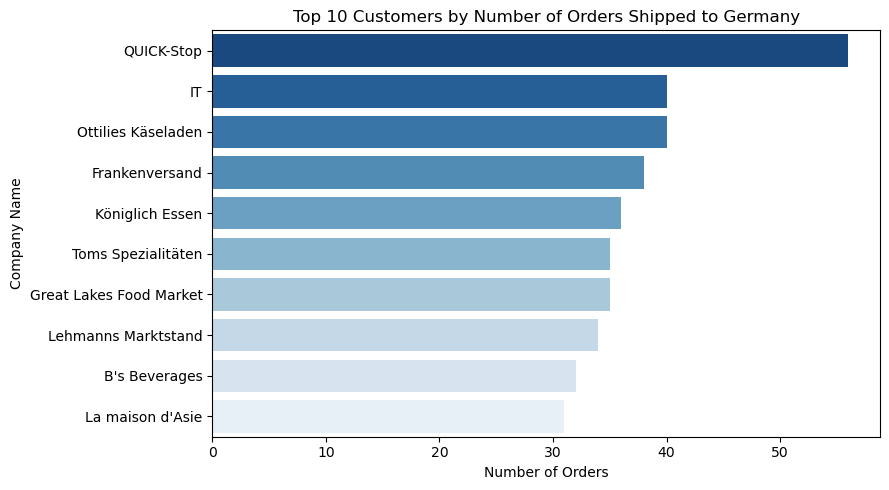

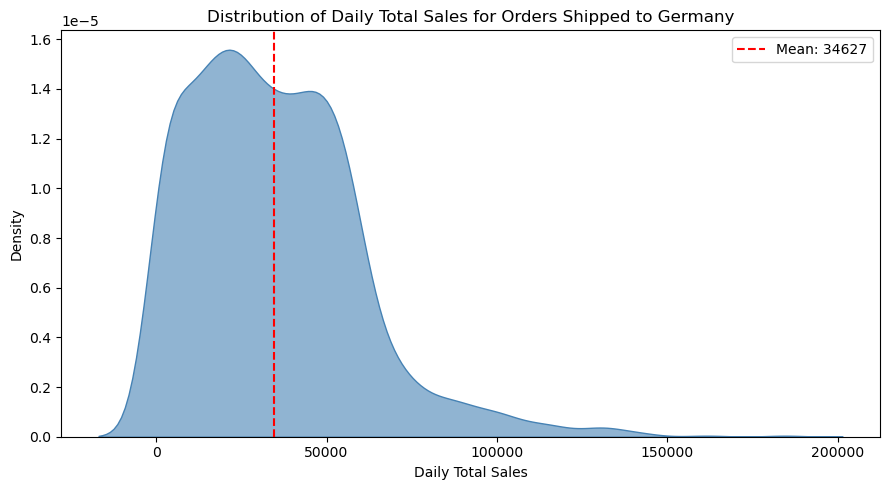

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


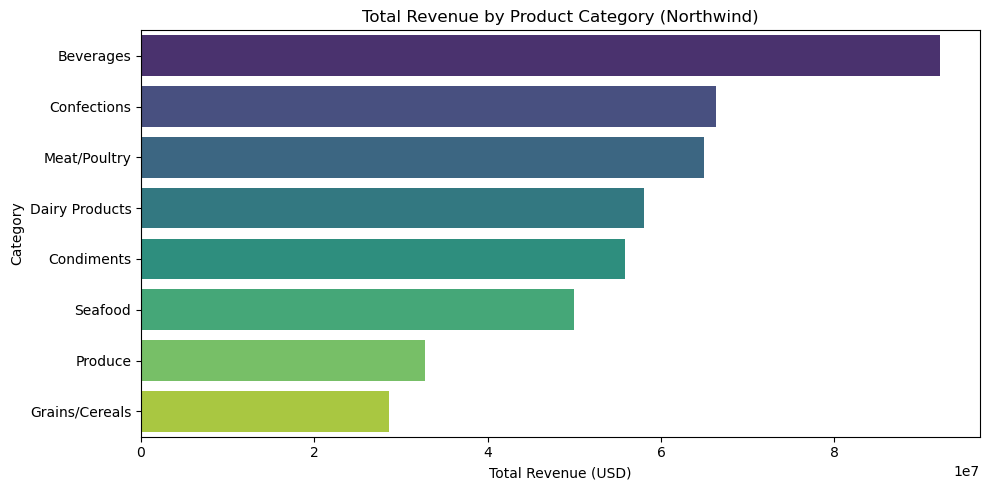

In [8]:
# a) Top 10 customers by number of orders to Germany
order_counts = (
    df_c.groupby("CompanyName")["OrderID"]
    .nunique()                                       # count unique orders per customer to avoid duplicates
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
order_counts.columns = ["CompanyName", "OrderCount"]

plt.figure(figsize=(9, 5))
sns.barplot(
    data=order_counts,
    x="OrderCount",
    y="CompanyName",                                 # company names on y-axis as they are long
    hue="CompanyName",
    palette="Blues_r",
    legend=False
)
plt.title("Top 10 Customers by Number of Orders Shipped to Germany")
plt.xlabel("Number of Orders")
plt.ylabel("Company Name")
plt.tight_layout()
plt.show()

# b) KDE plot of daily total sales to Germany
df_c["OrderDate"] = pd.to_datetime(df_c["OrderDate"], format="mixed").dt.date  # strip time component from datetime

daily_sales = (
    df_c.groupby("OrderDate")["LineTotal"]
    .sum()                                           # sum all line totals per day
    .reset_index()
)
daily_sales.columns = ["OrderDate", "DailyTotal"]

plt.figure(figsize=(9, 5))
sns.kdeplot(
    data=daily_sales,
    x="DailyTotal",
    fill=True,                                       # fill area under the curve
    color="steelblue",
    alpha=0.6
)
mean_sales = daily_sales["DailyTotal"].mean()
plt.axvline(x=mean_sales, color="red", linestyle="--", label=f"Mean: {mean_sales:.0f}")  # mean reference line
plt.legend()
plt.title("Distribution of Daily Total Sales for Orders Shipped to Germany")
plt.xlabel("Daily Total Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# c) Total revenue by product category
query_6c = """
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC
"""
df_6c = pd.read_sql(query_6c, conn)                  # load query result into DataFrame
display(df_6c)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_6c,
    x="TotalRevenue",
    y="CategoryName",
    hue="CategoryName",
    palette="viridis",
    legend=False
)
plt.title("Total Revenue by Product Category (Northwind)")
plt.xlabel("Total Revenue (USD)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Task 7: Comparing Python to SQL (1p)

a) Write a SQL query that retrieves the full `Products` table and the full `Categories` table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on `CategoryID`.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using `%%time` or `time.time()`, compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [9]:
# a) Retrieve Products and Categories tables
df_products = pd.read_sql("SELECT * FROM Products", conn)    # load full Products table
print("Products table:")
display(df_products.head())

df_categories = pd.read_sql("SELECT * FROM Categories", conn)  # load full Categories table
print("Categories table:")
display(df_categories.head())

# b) Inner join with pandas
df_merged = pd.merge(
    df_products,
    df_categories,
    on="CategoryID",                                 # join key present in both tables
    how="inner"                                      # keep only rows with matching CategoryID
)
print(f"Products: {df_products.shape}, Categories: {df_categories.shape}, Merged: {df_merged.shape}")
display(df_merged.head())

# c) Speed comparison: SQL vs pandas
# Method 1: Pure SQL
start_sql = time.time()                              # start timer

query_sql = """
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC
"""
df_result_sql = pd.read_sql(query_sql, conn)         # all joins and aggregation done inside the database

end_sql = time.time()
sql_time = end_sql - start_sql                       # total SQL execution time

print("SQL result:")
display(df_result_sql)
print(f"SQL execution time: {sql_time:.4f} seconds")

# Method 2: pandas for all calculations
start_pandas = time.time()                           # start timer

df_od = pd.read_sql("SELECT * FROM 'Order Details'", conn)  # load full Order Details table into memory
df_prod = pd.read_sql("SELECT * FROM Products", conn)        # load full Products table into memory
df_cat = pd.read_sql("SELECT * FROM Categories", conn)       # load full Categories table into memory

df_joined = df_od.merge(df_prod, on="ProductID", how="inner")       # first join
df_joined = df_joined.merge(df_cat, on="CategoryID", how="inner")   # second join

df_joined["Revenue"] = df_joined["UnitPrice_x"] * df_joined["Quantity"]  # UnitPrice_x is from Order Details
df_result_pandas = (
    df_joined.groupby("CategoryName")["Revenue"]
    .sum()
    .reset_index()
    .rename(columns={"Revenue": "TotalRevenue"})
    .sort_values("TotalRevenue", ascending=False)
)

end_pandas = time.time()
pandas_time = end_pandas - start_pandas              # total pandas execution time

print("Pandas result:")
display(df_result_pandas)
print(f"Pandas execution time: {pandas_time:.4f} seconds")

# Comparison
print("=" * 40)
print(f"SQL execution time:    {sql_time:.4f} seconds")
print(f"Pandas execution time: {pandas_time:.4f} seconds")
if sql_time < pandas_time:
    print(f"SQL was faster by {pandas_time - sql_time:.4f} seconds")
else:
    print(f"Pandas was faster by {sql_time - pandas_time:.4f} seconds")

Products table:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories table:


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


Products: (77, 10), Categories: (8, 4), Merged: (77, 13)


...

SQL result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


SQL execution time: 0.5866 seconds
Pandas result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
2,Confections,66347544.94
5,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
1,Condiments,55802774.45
7,Seafood,49931965.52
6,Produce,32706403.90
4,Grains/Cereals,28573512.55


Pandas execution time: 1.0856 seconds
SQL execution time:    0.5866 seconds
Pandas execution time: 1.0856 seconds
SQL was faster by 0.4990 seconds


 Comment on Results

SQL was faster than the pandas approach. This is expected because:
1.SQL performs the JOIN and GROUP BY directly inside the database engine,
  returning only the final 8-row summary to Python.
2.The pandas approach first loads all raw data from three tables into memory,
  then performs the calculations in Python, which involves more data transfer
  and memory usage.

### Task 8: Wide and long format (1p)

You are given two datasets. The first is in wide format:

```python
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
```

The second is in long format:

```python
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
```

a) Convert `wide_data` from wide to long format using `pd.melt()`. Print the DataFrame before and after conversion.

b) Convert `long_data` from long to wide format using `.pivot()`. Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [10]:
# Original datasets
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

# a) Wide to long with pd.melt()
print("Before (wide format):")
display(wide_data)

wide_to_long = pd.melt(
    wide_data,
    id_vars=["store"],                               # column to keep as identifier
    var_name="quarter",                              # original column names become values in this column
    value_name="sales"                               # the actual sales numbers go into this column
)
print("After (long format):")
display(wide_to_long)

# b) Long to wide with .pivot()
print("Before (long format):")
display(long_data)

long_to_wide = long_data.pivot(
    index="month",                                   # this column becomes the row index
    columns="product",                               # unique values here become new column names
    values="units_sold"                              # values to fill into the new columns
).reset_index()                                      # move month back to a regular column
long_to_wide.columns.name = None                     # remove column axis name for cleaner display

print("After (wide format):")
display(long_to_wide)

# c) Converting back to original format
print("wide_to_long → back to wide:")
display(wide_to_long)

restored_wide = wide_to_long.pivot(
    index="store",                                   # each store becomes a row
    columns="quarter",                               # quarter values become column names
    values="sales"                                   # fill cells with sales numbers
).reset_index()                                      # move store back to a regular column
restored_wide.columns.name = None                    # remove column axis name
restored_wide = restored_wide[["store", "Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"]]  # restore original column order

print("After (restored):")
display(restored_wide)
print("Matches original wide_data:", restored_wide.equals(wide_data))

print("long_to_wide → back to long:")
display(long_to_wide)

restored_long = pd.melt(
    long_to_wide,
    id_vars=["month"],                               # keep month as identifier
    var_name="product",                              # column names become product values
    value_name="units_sold"                          # fill values into units_sold column
).sort_values(["month", "product"]).reset_index(drop=True)  # sort to match original row order

print("After (restored):")
display(restored_long)

original_sorted = long_data.sort_values(["month", "product"]).reset_index(drop=True)  # sort original the same way for comparison
print("Matches original long_data:", restored_long.equals(original_sorted))

Before (wide format):


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


After (long format):


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


Before (long format):


...

Matches original wide_data: True
long_to_wide → back to long:


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


After (restored):


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130


Matches original long_data: True
